### Character Level Language Model

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

Modelling local structure of words in this case names

In [3]:
min_len = min(len(w) for w in words)
max_len = max(len(w) for w in words)
min_len, max_len

(2, 15)

Creating training data

In [12]:
b = {}

for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] # add start and end tokens
    for ch1, ch2 in zip(chs, chs[1:]): # creating bigrams
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
    # break

In [ ]:
b # This shows the pattern of characters that tend to follow each other in the dataset

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [15]:
sorted_bigrams = sorted(b.items(), key=lambda x: x[1], reverse=True)
sorted_bigrams[:10]  # Top 10 most common bigrams

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

In [19]:
# We can represent in 2D matrix in pytorch

import torch

a = torch.zeros((28, 28), dtype=torch.int32) # 28 chars including <S> and <E>
a[0, 1] = 3  # <S> to 'a' appeared 3 times
a[1, 2] = 5  # 'a' to 'b' appeared 5 times
a[:2]

tensor([[0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]], dtype=torch.int32)

In [20]:
# We need a looker to convert chars to integers and vice versa
chars = sorted(list(set(''.join(words))))
stoi = {ch: i for i, ch in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27
itos = {i: ch for i, ch in enumerate(chars)}
itos[26] = '<S>'
itos[27] = '<E>'

N = torch.zeros((28, 28), dtype=torch.int32)

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1
# We have a metrix with 2D showcasing frequency

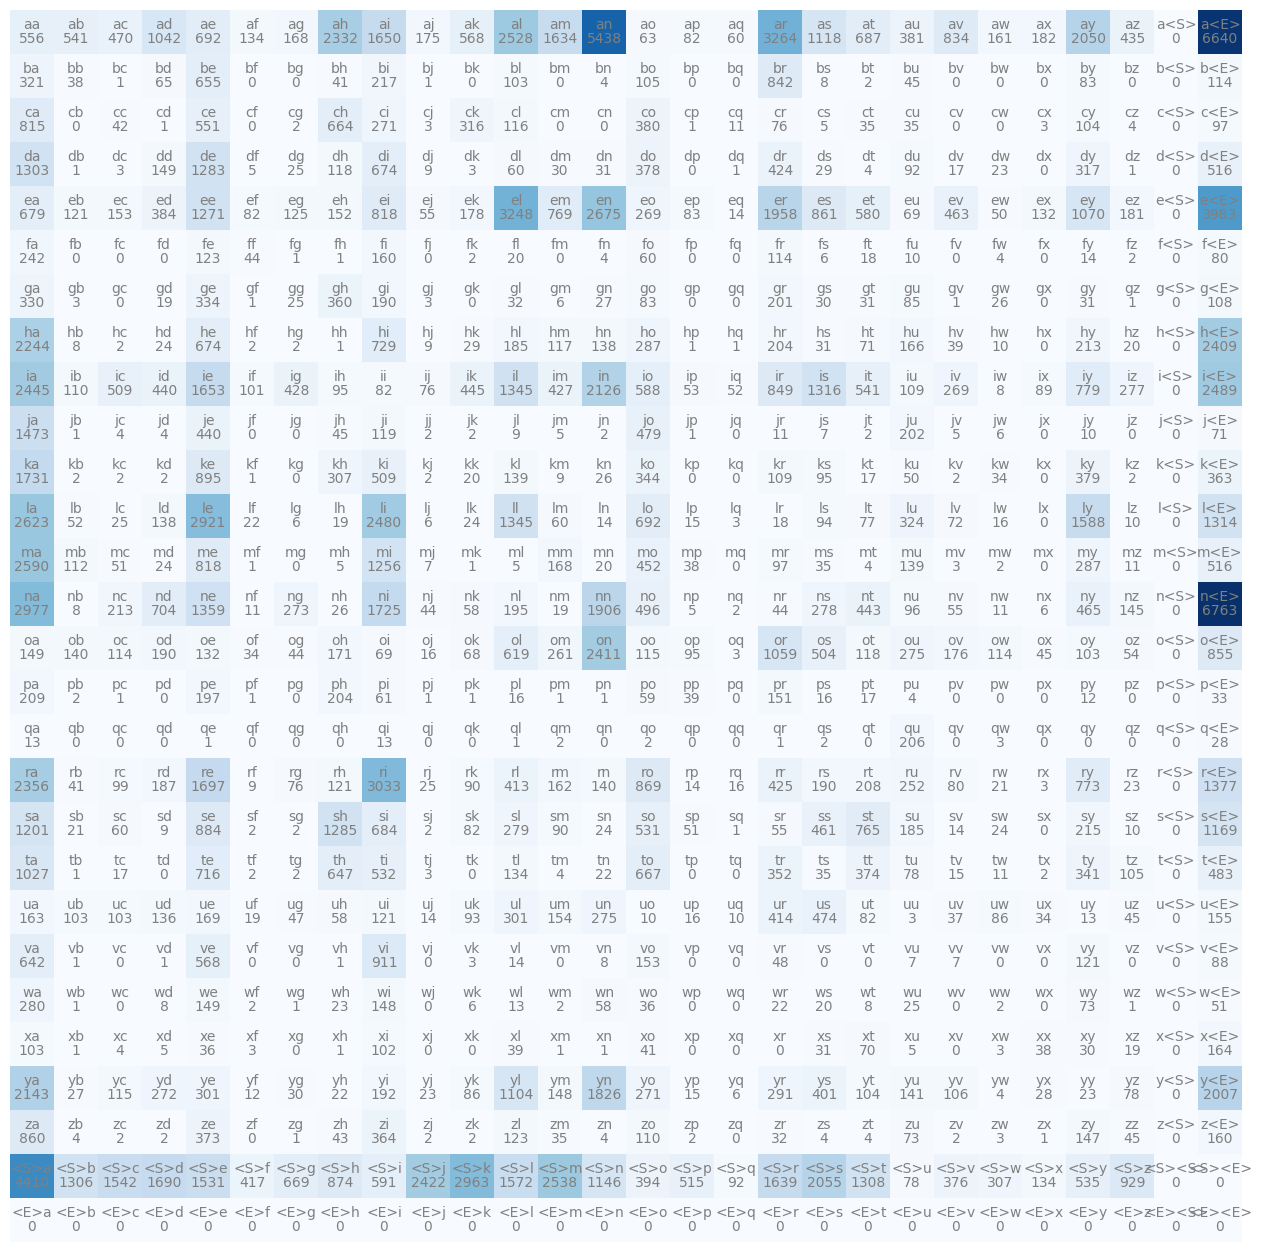

In [24]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off');

Lets do with only one special character

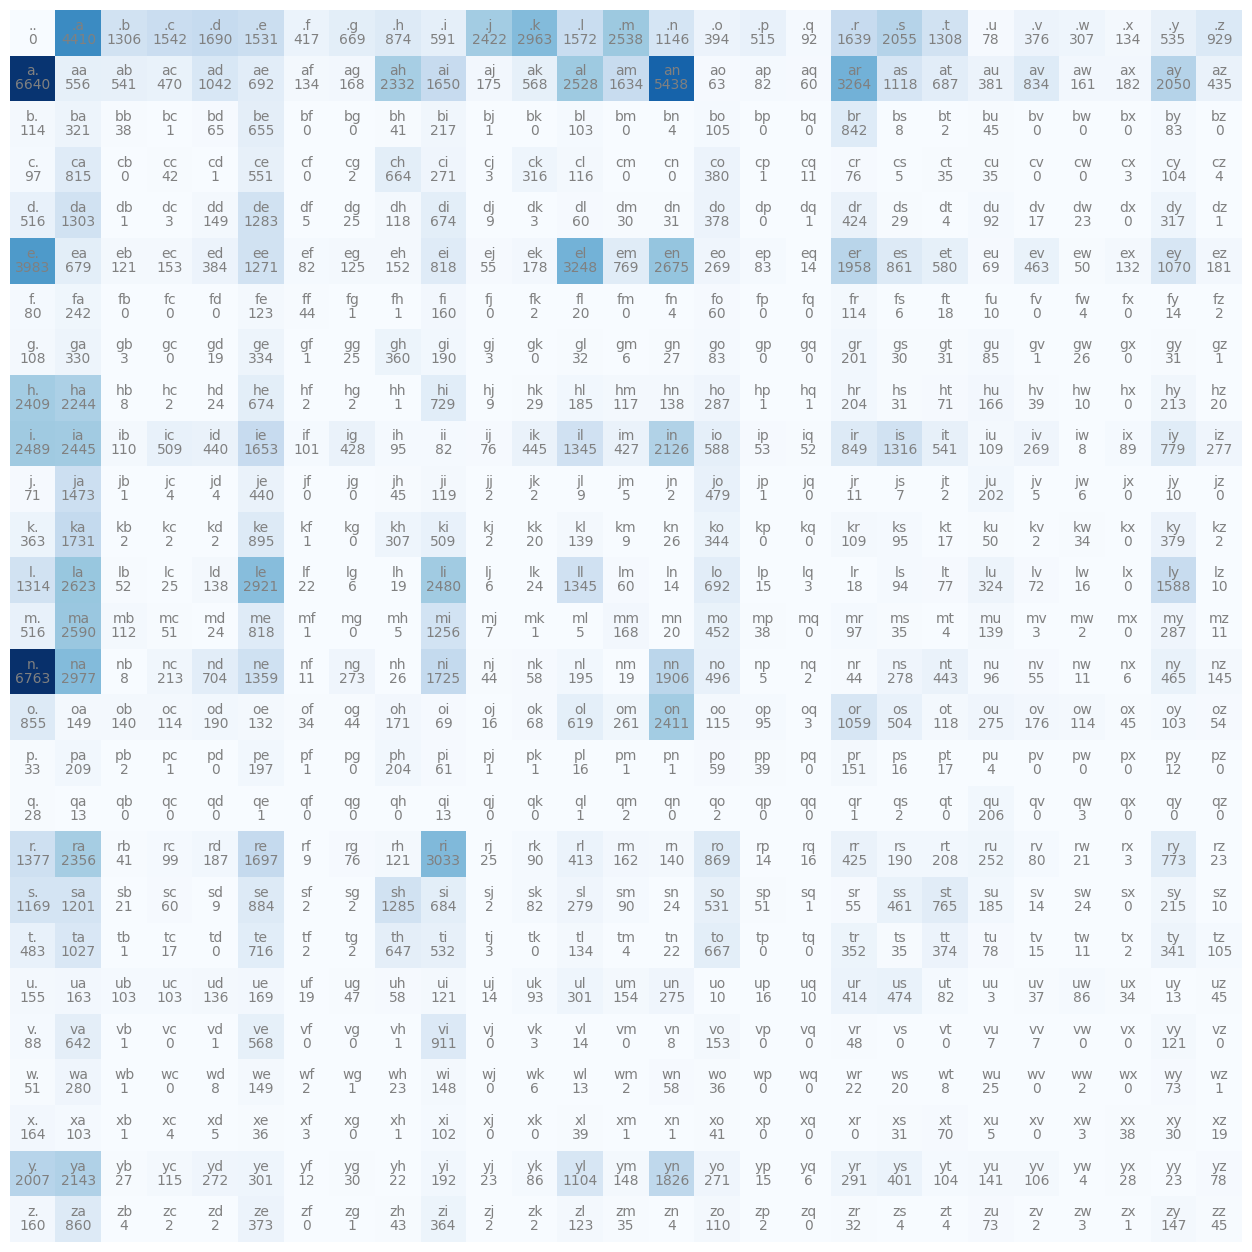

In [48]:
N = torch.zeros((27, 27), dtype=torch.int32)

chars = sorted(list(set(''.join(words))))
stoi = {ch: i+1 for i, ch in enumerate(chars)} # Offsetting by 1
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}


for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off');


In [26]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [27]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [32]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [35]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 0, 1, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [37]:
# Lets make the words based on probabilities
g = torch.Generator().manual_seed(2147483647)
for _ in range(20):  # generate 20 words
    out = []
    ix = 0  # start with the '.' character
    while True:
        p = N[ix].float() # Starting with frequency distribution of current character across 27 characters
        # print("p before:", p)
        p = p / p.sum() # normalizing to get probabilities
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        ch = itos[ix]
        if ch == '.':
            break
        out.append(ch)
    print(''.join(out))

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda
ka
emimmsade
enkaviyny
ftlspihinivenvorhlasu
dsor
br
jol
pen
aisan
ja


BiGram Language Model aint good. Just based on probabilities. If we start with uniform ditribution no relation at all. It is worst as compared to probability based BiGram LM

In [61]:
# Normalising the matrix to get probabilities
P = (N + 1).float() # adding 1 for laplace smoothing so that no entry is zero and we dont get zero probabilities leading to MLE exploding
P = P / P.sum(dim=1, keepdim=True)  # normalizing each row

In [ ]:
# print(P.sum(0, keepdim=True).shape) # dim=0 is columns, dim=1 is rows
# print(P.sum(1, keepdim=True).shape)

torch.Size([1, 27])
torch.Size([27, 1])


In [50]:
# Lets make the words based on probabilities
g = torch.Generator().manual_seed(2147483647)
for _ in range(5):  # generate 20 words
    out = []
    ix = 0  # start with the '.' character
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        ch = itos[ix]
        if ch == '.':
            break
        out.append(ch)
    print(''.join(out))

cexze
momasurailezitynn
konimittain
llayn
ka


### Evaluation of the model

In [ ]:
# a*b*c
# log(a*b*c) = log(a) + log(b) + log(c)


In [ ]:
log_likelihood = 0.0
negative_log_likelihood = 0.0
n=0

for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob.item()
        n += 1
        print(f'{ch1}{ch2} (prob: {prob:.4f})')

print(f'Log-likelihood: {log_likelihood:.4f}')
negative_log_likelihood = -log_likelihood # Needs to be minimised
print(f'Negative Log-likelihood: {negative_log_likelihood:.4f}')
print("Average NLL per character:", negative_log_likelihood / n) # Need to minimise this

.e (prob: 0.0478)
em (prob: 0.0377)
mm (prob: 0.0253)
ma (prob: 0.3899)
a. (prob: 0.1960)
.o (prob: 0.0123)
ol (prob: 0.0780)
li (prob: 0.1777)
iv (prob: 0.0152)
vi (prob: 0.3541)
ia (prob: 0.1381)
a. (prob: 0.1960)
.a (prob: 0.1377)
av (prob: 0.0246)
va (prob: 0.2495)
a. (prob: 0.1960)
Log-likelihood: -38.7856
Negative Log-likelihood: 38.7856
Average NLL per character: 2.4241023175418377


- We want probabillity to be high
- MLE - Maximum Likelihood Estimation at work

In [62]:
log_likelihood = 0.0
negative_log_likelihood = 0.0
n=0

# ALL WORDS

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob.item()
        n += 1
        # print(f'{ch1}{ch2} (prob: {prob:.4f})')

print(f'Log-likelihood: {log_likelihood:.4f}')
negative_log_likelihood = -log_likelihood # Needs to be minimised
print(f'Negative Log-likelihood: {negative_log_likelihood:.4f}')
print("Average NLL per character:", negative_log_likelihood / n) # Need to minimise this

Log-likelihood: -560001.8847
Negative Log-likelihood: 560001.8847
Average NLL per character: 2.454576826578749


In [63]:
log_likelihood = 0.0
negative_log_likelihood = 0.0
n=0

for w in ['andrejq', 'radheka', 'sarada']:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob.item()
        n += 1
        # print(f'{ch1}{ch2} (prob: {prob:.4f})')

print(f'Log-likelihood: {log_likelihood:.4f}')
negative_log_likelihood = -log_likelihood # Needs to be minimised
print(f'Negative Log-likelihood: {negative_log_likelihood:.4f}')
print("Average NLL per character:", negative_log_likelihood / n) # Need to minimise this

Log-likelihood: -64.9561
Negative Log-likelihood: 64.9561
Average NLL per character: 2.8241801521052485


Handling inf by smoothening the model by adding 1

### NN Approach

In [64]:
# Character Level language Model, Loss function -> optimisation

# Training data creation
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [65]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [ ]:
# How to convert indices to one hot vectors
import torch.nn.functional as F
x_enc = F.one_hot(xs, num_classes=27).float() # Cast to float for input to neural network
x_enc.shape

torch.Size([228146, 27])

In [ ]:
# Imagine it as a single layer neural network with 27 inputs and 1 output neuron
W = torch.randn((27, 1)) # weights initialization | 1 neuron
y_pred = x_enc @ W  # matrix multiplication | n, 27  x  27,1  = n,1 | multiply and add
y_pred.shape

torch.Size([228146, 1])

In [ ]:
# Imagine it as a single layer neural network with 27 inputs and 27 output neurons
# Each output neuron corresponds to one of the 27 characters
W2 = torch.randn((27, 27)) # weights initialization | 27 outputs for 27 characters

# linear layers with no non-linear activation
Y_pred = x_enc @ W2  # n,27
Y_pred[:5]

# each row corresponds to one training example
# each column corresponds to one of the 27 characters and the value is the score (unnormalized log prob) for that character
# But we need probabilities, so we apply softmax


tensor([[-0.2485, -0.2231, -0.8443, -1.6389, -0.8076,  0.2099,  0.4281,  1.2751,
         -1.1416, -0.4180, -1.6961,  1.1417, -1.2753, -0.0687,  1.0927,  0.2634,
          0.4561, -0.2499, -0.6867, -1.2742, -1.1866, -0.5281, -0.0594,  0.7071,
         -0.4710, -1.2121,  0.7152],
        [-0.2997, -0.2978, -2.3866,  0.1751, -0.0257,  0.0350,  0.5961,  0.4721,
         -1.1357, -0.7164,  0.2081,  0.1354,  1.7446,  2.0772, -0.2388, -0.3130,
         -0.3788,  0.4838, -0.8518,  0.1191,  1.3539, -0.2184,  1.1245, -1.4197,
          0.6401,  0.2820, -0.3816],
        [ 0.6184, -0.9755,  0.3030, -0.3003,  0.7940,  1.0248,  0.0637,  1.5659,
          0.6922,  1.1045,  0.0370,  0.5000,  1.4098, -2.0729, -0.4026, -0.5134,
          0.3933, -0.9585,  0.0076, -0.8438, -0.3035,  1.1633, -0.2023,  0.0959,
          0.3619, -0.3041, -0.0665],
        [ 0.6184, -0.9755,  0.3030, -0.3003,  0.7940,  1.0248,  0.0637,  1.5659,
          0.6922,  1.1045,  0.0370,  0.5000,  1.4098, -2.0729, -0.4026, -0.5134

In [78]:
logits = x_enc @ W2 # log-counts
counts = logits.exp() # exponentiating the scores to get positive values
probs = counts / counts.sum(1, keepdim=True) # normalizing to get probabilities
probs.shape

# Row that came out of NN and we applied softmax to get probabilities
probs[0]  # probabilities for the first training example

tensor([0.0271, 0.0278, 0.0149, 0.0068, 0.0155, 0.0429, 0.0534, 0.1245, 0.0111,
        0.0229, 0.0064, 0.1089, 0.0097, 0.0325, 0.1037, 0.0453, 0.0549, 0.0271,
        0.0175, 0.0097, 0.0106, 0.0205, 0.0328, 0.0705, 0.0217, 0.0103, 0.0711])

In [79]:
# We need to optimise the weights W2 such that the probs match the actual distribution of next characters in the training data

nlls = torch.zeros(5)
for i in range(5):
    prob = probs[i, ys[i]]  # probability assigned to the correct next character
    nll = -torch.log(prob)  # negative log likelihood
    nlls[i] = nll
print('Average NLL for first 5 examples:', nlls.mean().item())

Average NLL for first 5 examples: 3.6595444679260254


In [ ]:
# randomly initialised weights will give high NLL, we need to optimise them to reduce NLL

g = torch.Generator().manual_seed(2147483647)
W2 = torch.randn((27, 27), generator=g, requires_grad=True)


In [105]:

# Forward pass
logits = x_enc @ W2
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(len(ys)), ys].log().mean()  # average NLL loss | calculating BCE loss manually


In [106]:

W2.grad = None  # gradients are None before backward pass
loss.backward()  # backward pass to compute gradients

In [107]:
W2.grad.shape # We want to update all weights based on gradients

torch.Size([27, 27])

In [108]:
W2.data = W2.data - 0.1 * W2.grad  # SGD update with learning rate 0.1

In [109]:
loss

tensor(3.7562, grad_fn=<NegBackward0>)

### Clean Approach

In [110]:
# Character Level language Model, Loss function -> optimisation

# Training data creation
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

# randomly initialised weights will give high NLL, we need to optimise them to reduce NLL
g = torch.Generator().manual_seed(2147483647)
W2 = torch.randn((27, 27), generator=g, requires_grad=True)

In [113]:
for k in range(100):  # training loop
    # Forward pass
    logits = x_enc @ W2
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(len(ys)), ys].log().mean()  # average NLL loss | calculating BCE loss manually

    W2.grad = None  # gradients are None before backward pass
    loss.backward()  # backward pass to compute gradients

    W2.data = W2.data - 10 * W2.grad  # SGD update with learning rate 0.1

    if k % 10 == 0:
        print(f'Iteration {k}, Loss: {loss.item():.4f}')

Iteration 0, Loss: 3.1526
Iteration 10, Loss: 2.9307
Iteration 20, Loss: 2.8131
Iteration 30, Loss: 2.7407
Iteration 40, Loss: 2.6911
Iteration 50, Loss: 2.6547
Iteration 60, Loss: 2.6269
Iteration 70, Loss: 2.6052
Iteration 80, Loss: 2.5879
Iteration 90, Loss: 2.5739


Sampling the model

In [ ]:
for i in range(5):
    out = []
    ix = 0

    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W2 # Weight is already computed
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

jja.
aanie.
kin.
kliabrelemava.
ashler.


2 ways of training the model:
1. Frequency based (as shown earlier)
2. Manually computing gradients and updating weights (as shown above)